<a href="https://colab.research.google.com/github/hanxskuy/Skripshuy/blob/main/bimbingan_after_sidang_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**INSTALL LIBRARY**

In [3]:
!pip install nibabel -q

**IMPORT LIBRARY**

In [4]:
import os
import cv2
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nibabel as nib
import tensorflow as tf

from tqdm import tqdm
from sklearn.model_selection import train_test_split

from tensorflow.keras import backend as K
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

**DOWNLOAD DATASET DARI KAGGLE**

In [5]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "andrewmvd/liver-tumor-segmentation"
)

print("Dataset tersimpan di:", dataset_path)

100%|██████████| 4.84G/4.84G [03:49<00:00, 22.6MB/s]

Extracting files...


Dataset tersimpan di: /root/.cache/kagglehub/datasets/andrewmvd/liver-tumor-segmentation/versions/5


**CEK FILE DATASET**

In [6]:
nii_files = sorted(
    glob.glob(dataset_path + "/**/*.nii", recursive=True)
)

nii_gz_files = sorted(
    glob.glob(dataset_path + "/**/*.nii.gz", recursive=True)
)

all_files = nii_files + nii_gz_files

print("Jumlah File :", len(all_files))

Jumlah File : 182


**PISAHKAN CT DAN MASK**

In [7]:
ct_files = []
mask_files = []

for file in all_files:

    filename = os.path.basename(file)

    if "volume" in filename.lower():
        ct_files.append(file)

    elif "segmentation" in filename.lower():
        mask_files.append(file)

print("Jumlah CT Scan :", len(ct_files))
print("Jumlah Mask    :", len(mask_files))


Jumlah CT Scan : 51
Jumlah Mask    : 131


**VISUALISASI SAMPLE CT SCAN**

Shape CT Scan : (512, 512, 75)
Shape Mask    : (512, 512, 75)


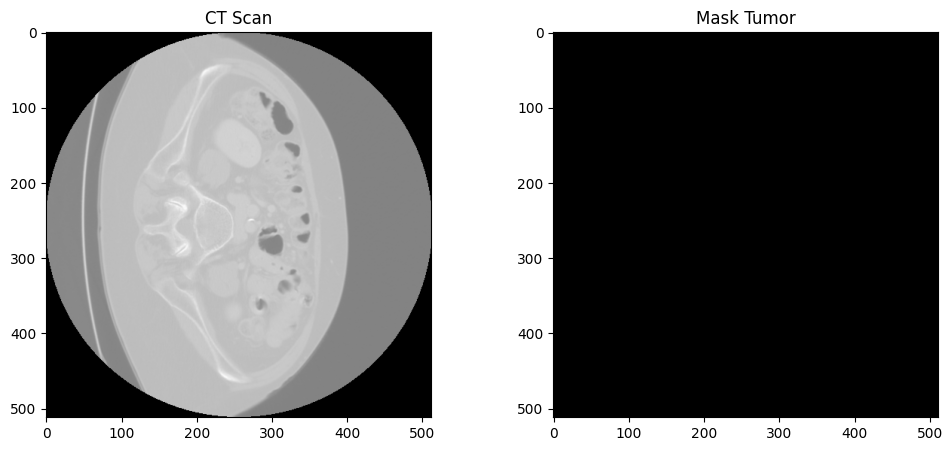

In [8]:
sample_ct = nib.load(ct_files[0]).get_fdata()
sample_mask = nib.load(mask_files[0]).get_fdata()

print("Shape CT Scan :", sample_ct.shape)
print("Shape Mask    :", sample_mask.shape)

slice_idx = sample_ct.shape[2] // 2

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(sample_ct[:,:,slice_idx], cmap='gray')
plt.title("CT Scan")

plt.subplot(1,2,2)
plt.imshow(sample_mask[:,:,slice_idx], cmap='gray')
plt.title("Mask Tumor")

plt.show()

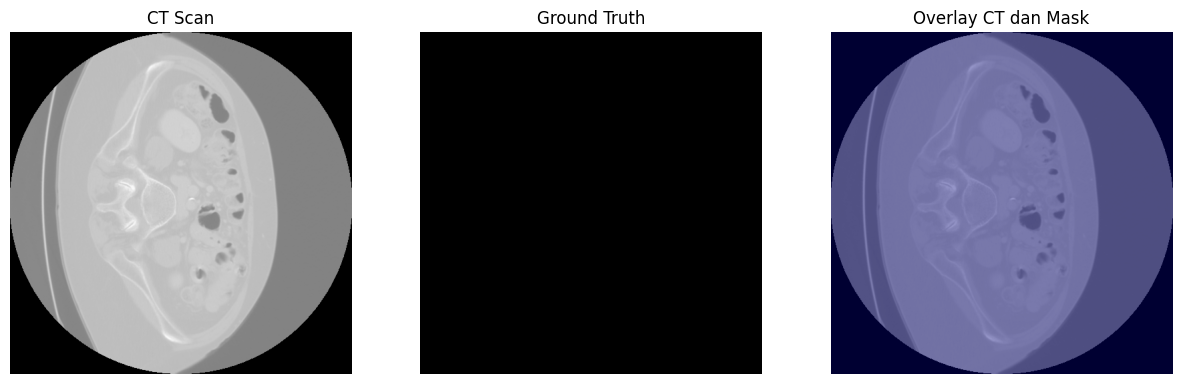

In [9]:
slice_idx = sample_ct.shape[2] // 2

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(sample_ct[:,:,slice_idx], cmap='gray')
plt.title("CT Scan")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(sample_mask[:,:,slice_idx], cmap='gray')
plt.title("Ground Truth")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(sample_ct[:,:,slice_idx], cmap='gray')
plt.imshow(sample_mask[:,:,slice_idx], cmap='jet', alpha=0.4)
plt.title("Overlay CT dan Mask")
plt.axis('off')

plt.show()

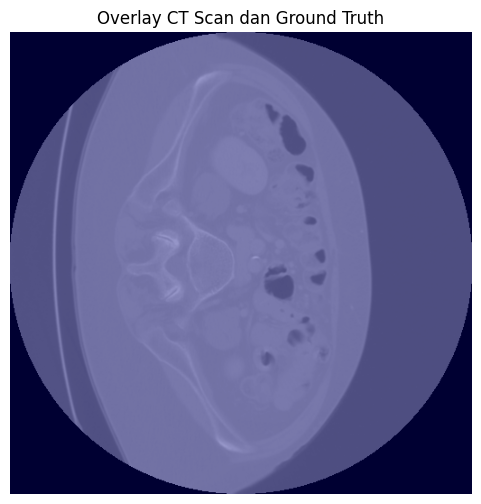

In [10]:
# ==========================================
# OVERLAY CT DAN MASK
# ==========================================

plt.figure(figsize=(6,6))

plt.imshow(sample_ct[:,:,slice_idx], cmap='gray')
plt.imshow(sample_mask[:,:,slice_idx], cmap='jet', alpha=0.4)

plt.title("Overlay CT Scan dan Ground Truth")
plt.axis('off')

plt.show()

In [11]:
# ==========================================
# CEK LABEL DATASET
# ==========================================

print("Label yang ditemukan:")
print(np.unique(sample_mask))

Label yang ditemukan:
[0. 1. 2.]


In [12]:
# ==========================================
# DISTRIBUSI LABEL SEGMENTASI
# ==========================================

all_counts = np.zeros(3)

for mask_file in mask_files:
    mask = nib.load(mask_file).get_fdata()

    unique, counts = np.unique(mask, return_counts=True)

    for u, c in zip(unique, counts):
        all_counts[int(u)] += c

print(all_counts)

[1.50203702e+10 3.32764489e+08 1.84651940e+07]


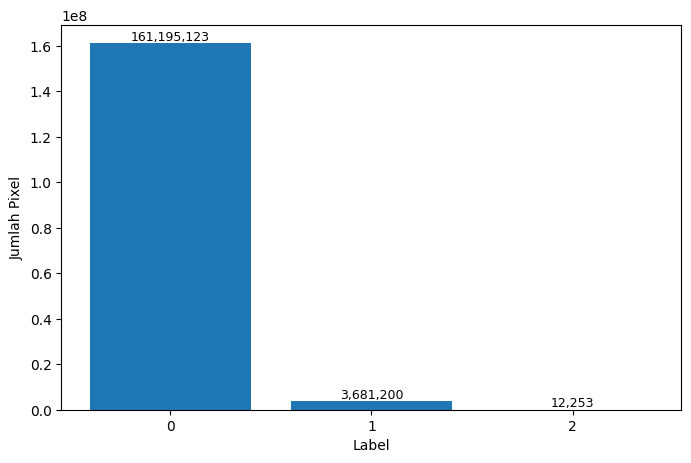

In [13]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    ['0','1','2'],
    counts
)

for bar in bars:
    y = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        y,
        f'{int(y):,}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.ylabel("Jumlah Pixel")
plt.xlabel("Label")
plt.show()

In [14]:
# ==========================================
# JUMLAH DATASET
# ==========================================

print("Jumlah CT Scan :", len(ct_files))
print("Jumlah Mask    :", len(mask_files))

Jumlah CT Scan : 51
Jumlah Mask    : 131


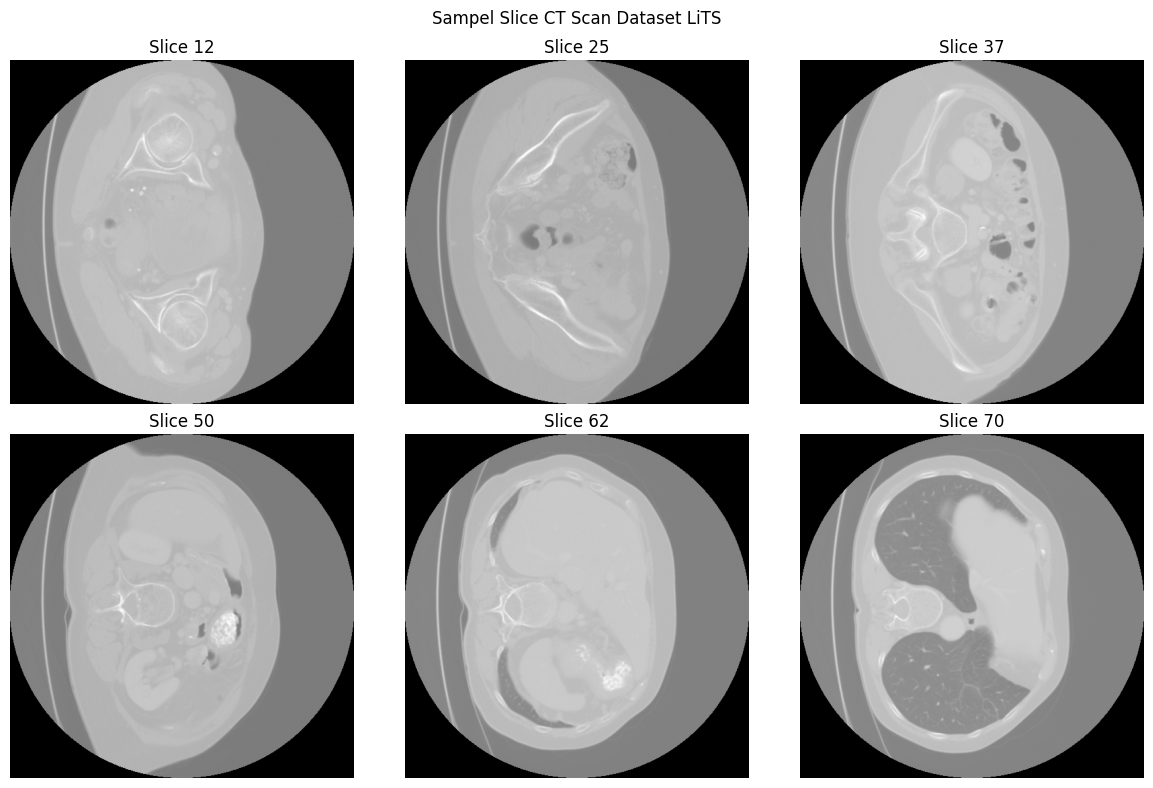

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(12,8))

slice_indices = [
    sample_ct.shape[2]//6,
    sample_ct.shape[2]//3,
    sample_ct.shape[2]//2,
    sample_ct.shape[2]*2//3,
    sample_ct.shape[2]*5//6,
    sample_ct.shape[2]-5
]

for ax, idx in zip(axes.flatten(), slice_indices):
    ax.imshow(sample_ct[:,:,idx], cmap='gray')
    ax.set_title(f"Slice {idx}")
    ax.axis('off')

plt.suptitle("Sampel Slice CT Scan Dataset LiTS")
plt.tight_layout()
plt.show()

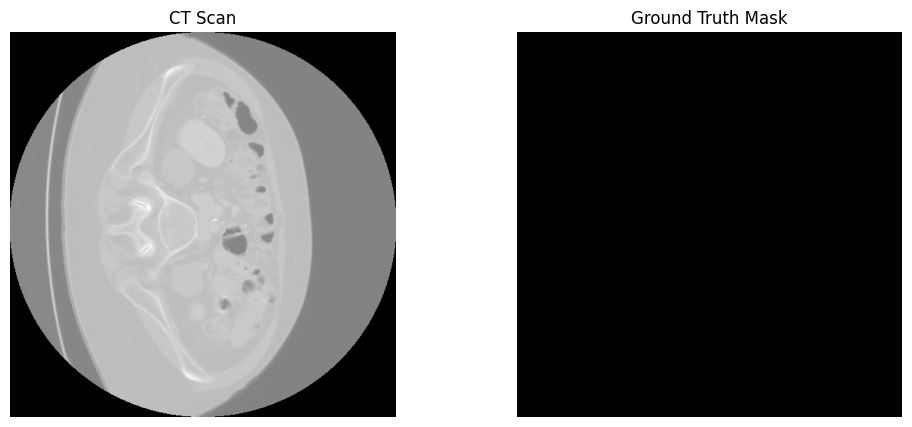

In [16]:
slice_idx = sample_ct.shape[2] // 2

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(sample_ct[:,:,slice_idx], cmap='gray')
plt.title("CT Scan")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(sample_mask[:,:,slice_idx], cmap='gray')
plt.title("Ground Truth Mask")
plt.axis('off')

plt.show()

In [28]:
print(dataset_path)

import os
print(os.listdir(dataset_path))

/root/.cache/kagglehub/datasets/andrewmvd/liver-tumor-segmentation/versions/5
['volume_pt5', 'volume_pt1', 'volume_pt4', 'volume_pt3', 'volume_pt2', 'segmentations']


Jumlah pasangan data: 51

Contoh pasangan data:
volume-0.nii <--> segmentation-0.nii
volume-1.nii <--> segmentation-1.nii
volume-2.nii <--> segmentation-2.nii
volume-3.nii <--> segmentation-3.nii
volume-4.nii <--> segmentation-4.nii

Pasien 0
CT Shape   : (512, 512, 75)
Mask Shape : (512, 512, 75)
Slice terpilih : 65


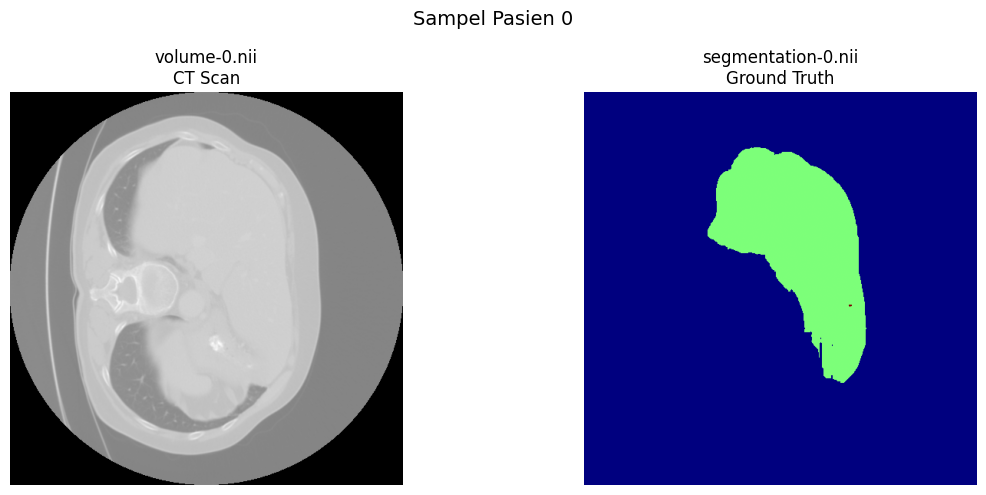


Pasien 1
CT Shape   : (512, 512, 123)
Mask Shape : (512, 512, 123)
Slice terpilih : 65


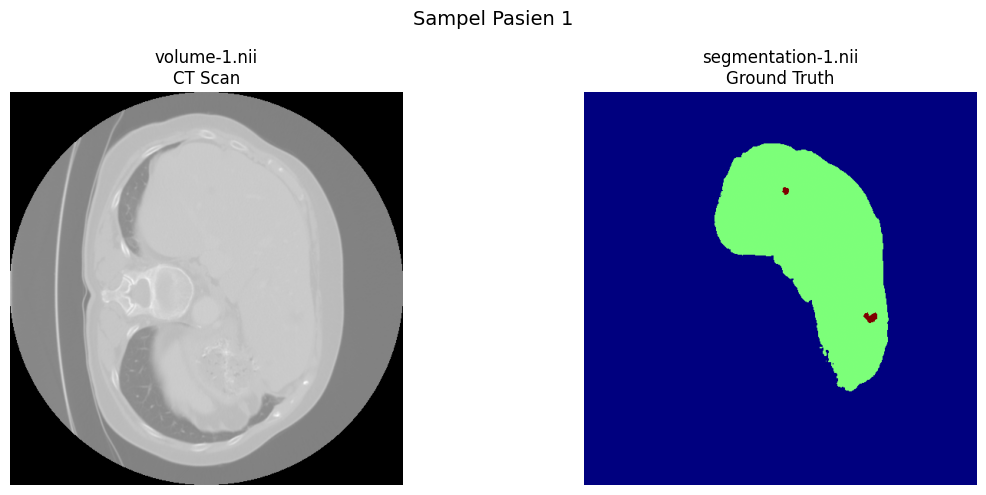


Pasien 2
CT Shape   : (512, 512, 517)
Mask Shape : (512, 512, 517)
Slice terpilih : 454


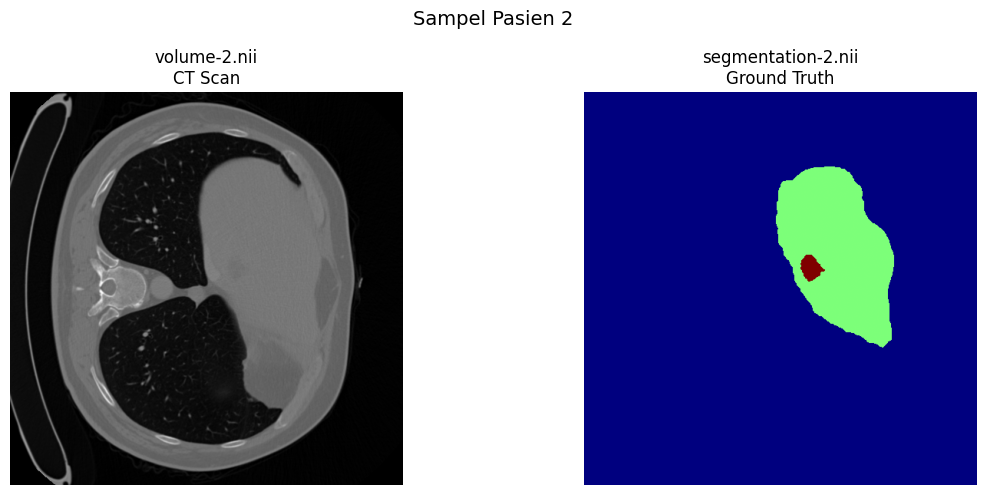


Pasien 10
CT Shape   : (512, 512, 501)
Mask Shape : (512, 512, 501)
Slice terpilih : 375


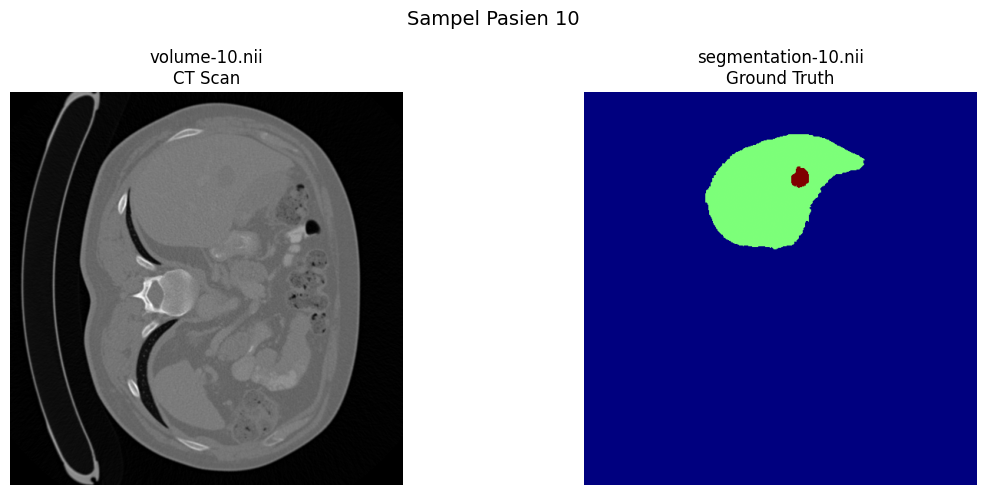

In [30]:
import os
import re
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# PATH DATASET
# ==================================================

base_dir = dataset_path

# ==================================================
# KUMPULKAN FILE CT SCAN
# ==================================================

ct_files = []

for folder in [
    "volume_pt1",
    "volume_pt2",
    "volume_pt3",
    "volume_pt4",
    "volume_pt5"
]:
    folder_path = os.path.join(base_dir, folder)

    ct_files.extend([
        os.path.join(folder_path, f)
        for f in os.listdir(folder_path)
        if f.endswith(".nii")
    ])

# ==================================================
# KUMPULKAN FILE SEGMENTASI
# ==================================================

mask_dir = os.path.join(base_dir, "segmentations")

mask_files = [
    os.path.join(mask_dir, f)
    for f in os.listdir(mask_dir)
    if f.endswith(".nii")
]

# ==================================================
# AMBIL ID PASIEN
# ==================================================

def get_id(path):
    filename = os.path.basename(path)
    return int(re.search(r'(\d+)', filename).group(1))

# ==================================================
# PAIRING CT DAN MASK
# ==================================================

ct_dict = {get_id(f): f for f in ct_files}
mask_dict = {get_id(f): f for f in mask_files}

common_ids = sorted(
    set(ct_dict.keys()) &
    set(mask_dict.keys())
)

print(f"Jumlah pasangan data: {len(common_ids)}")

# ==================================================
# CONTOH HASIL PAIRING
# ==================================================

print("\nContoh pasangan data:")

for pid in common_ids[:5]:
    print(
        os.path.basename(ct_dict[pid]),
        "<-->",
        os.path.basename(mask_dict[pid])
    )

# ==================================================
# PASIEN YANG DITAMPILKAN
# ==================================================

sample_ids = [0, 1, 2, 10]

# ==================================================
# VISUALISASI SAMPEL DATASET LiTS
# ==================================================

for pid in sample_ids:

    ct_path = ct_dict[pid]
    mask_path = mask_dict[pid]

    ct = nib.load(ct_path).get_fdata()
    mask = nib.load(mask_path).get_fdata()

    print(f"\nPasien {pid}")
    print("CT Shape   :", ct.shape)
    print("Mask Shape :", mask.shape)

    # Cari slice yang mengandung tumor
    tumor_slices = np.where(
        np.any(mask == 2, axis=(0, 1))
    )[0]

    # Ambil slice tengah yang mengandung tumor
    if len(tumor_slices) > 0:
        slice_idx = tumor_slices[
            len(tumor_slices)//2
        ]
    else:
        slice_idx = mask.shape[2] // 2

    print("Slice terpilih :", slice_idx)

    # ==========================================
    # VISUALISASI
    # ==========================================

    plt.figure(figsize=(12,5))

    # CT Scan
    plt.subplot(1,2,1)

    plt.imshow(
        ct[:, :, slice_idx],
        cmap="gray"
    )

    plt.title(
        f"volume-{pid}.nii\nCT Scan"
    )

    plt.axis("off")

    # Ground Truth
    plt.subplot(1,2,2)

    plt.imshow(
        mask[:, :, slice_idx],
        cmap="jet"
    )

    plt.title(
        f"segmentation-{pid}.nii\nGround Truth"
    )

    plt.axis("off")

    plt.suptitle(
        f"Sampel Pasien {pid}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

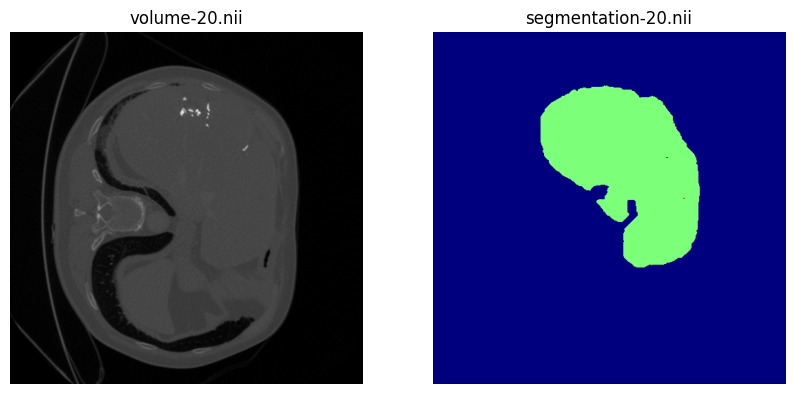

In [31]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

pid = 20

ct = nib.load(ct_dict[pid]).get_fdata()
mask = nib.load(mask_dict[pid]).get_fdata()

tumor_slices = np.where(
    np.any(mask == 2, axis=(0,1))
)[0]

slice_idx = tumor_slices[len(tumor_slices)//2]

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(ct[:,:,slice_idx], cmap='gray')
plt.title(f'volume-{pid}.nii')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(
    mask[:,:,slice_idx],
    cmap='jet',
    vmin=0,
    vmax=2
)
plt.title(f'segmentation-{pid}.nii')
plt.axis('off')

plt.show()

**PREPROCESSING**

In [32]:
IMG_SIZE = 128
# CLAHE
# =========================================================

def apply_clahe(image):

    image = np.uint8(image)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    return clahe.apply(image)

# =========================================================
# NORMALISASI
# =========================================================

def normalize_image(image):

    image = image - np.min(image)
    image = image / (np.max(image) + 1e-8)

    return image

# =========================================================
# PREPROCESS SLICE
# =========================================================

def preprocess_slice(image, mask):

    image = normalize_image(image)

    image = (image * 255).astype(np.uint8)

    image = apply_clahe(image)

    image = cv2.GaussianBlur(image, (3,3), 0)

    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

    image = image / 255.0

    mask = (mask > 0).astype(np.float32)

    image = np.expand_dims(image, axis=-1)
    mask = np.expand_dims(mask, axis=-1)

    return image, mask

**LOAD SEMUA SLICE**

In [33]:
images = []
masks = []

for ct_path, mask_path in tqdm(
    zip(ct_files, mask_files),
    total=min(len(ct_files), len(mask_files))
):

    ct_scan = nib.load(ct_path).get_fdata()
    mask_scan = nib.load(mask_path).get_fdata()

    # gunakan jumlah slice terkecil
    total_slices = min(
        ct_scan.shape[2],
        mask_scan.shape[2]
    )

    for i in range(total_slices):

        image_slice = ct_scan[:, :, i]
        mask_slice  = mask_scan[:, :, i]

        # skip slice kosong
        if np.max(mask_slice) > 0:

            image, mask = preprocess_slice(
                image_slice,
                mask_slice
            )

            images.append(image)
            masks.append(mask)

images = np.array(images, dtype=np.float32)
masks = np.array(masks, dtype=np.float32)

100%|██████████| 51/51 [01:51<00:00,  2.18s/it]


**SPLIT DATASET**

In [34]:
#VISUALISASI SAMPLE DATA
X_train, X_test, y_train, y_test = train_test_split(
    images,
    masks,
    test_size=0.2,
    random_state=42
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

Train : (3066, 128, 128, 1)
Test  : (767, 128, 128, 1)


**DATA AUGMENTATION**

In [35]:
augmentation = tf.keras.Sequential([

    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1)

])

**METRIC**

In [36]:
def dice_coef(y_true, y_pred):

    smooth = 1e-6

    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    intersection = K.sum(y_true_f * y_pred_f)

    return (
        (2. * intersection + smooth)
        /
        (
            K.sum(y_true_f)
            +
            K.sum(y_pred_f)
            +
            smooth
        )
    )

**IOU**

In [37]:
def iou_metric(y_true, y_pred):

    smooth = 1e-6

    intersection = K.sum(y_true * y_pred)

    union = (
        K.sum(y_true)
        +
        K.sum(y_pred)
        -
        intersection
    )

    return (
        intersection + smooth
    ) / (
        union + smooth
    )


In [38]:
# LOSS FUNCTION
# =========================================================

def dice_loss(y_true, y_pred):

    return 1 - dice_coef(y_true, y_pred)


**CONVOLUTION BLOCK**

In [39]:
def conv_block(x, filters):

    x = Conv2D(
        filters,
        3,
        padding="same"
    )(x)

    x = BatchNormalization()(x)

    x = Activation("relu")(x)

    x = Conv2D(
        filters,
        3,
        padding="same"
    )(x)

    x = BatchNormalization()(x)

    x = Activation("relu")(x)

    return x

**ATTENTION BLOCK**

In [40]:
def attention_block(gating, skip, filters):

    g1 = Conv2D(filters, 1)(gating)

    x1 = Conv2D(filters, 1)(skip)

    psi = Add()([g1, x1])

    psi = Activation("relu")(psi)

    psi = Conv2D(1, 1)(psi)

    psi = Activation("sigmoid")(psi)

    out = Multiply()([skip, psi])

    return out

**ENCODER BLOCK**

In [41]:
def encoder_block(x, filters):

    c = conv_block(x, filters)

    p = MaxPooling2D((2,2))(c)

    return c, p

**DECODER BLOCK**

In [42]:
def decoder_block(x, skip, filters):

    x = UpSampling2D((2,2))(x)

    skip = attention_block(
        x,
        skip,
        filters
    )

    x = Concatenate()([x, skip])

    x = conv_block(x, filters)

    return x

**BUILD ATTENTION U-NET**

In [43]:
def build_attention_unet(input_shape):

    inputs = Input(input_shape)

    # Encoder
    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    # Bottleneck
    b1 = conv_block(p4, 1024)

    # Decoder
    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    outputs = Conv2D(
        1,
        1,
        activation="sigmoid"
    )(d4)

    model = Model(inputs, outputs)

    return model

**BUILD MODEL**

In [44]:
model = build_attention_unet(
    (IMG_SIZE, IMG_SIZE, 1)
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_4[0][0]  

 Total params: 32,448,709 (123.78 MB)

 Trainable params: 32,436,933 (123.74 MB)

 Non-trainable params: 11,776 (46.00 KB)

**COMPILE MODEL**

In [45]:
model.compile(

    optimizer=Adam(1e-4),

    loss=dice_loss,

    metrics=[
        dice_coef,
        iou_metric,
        "accuracy"
    ]
)

**CALLBACK**

In [46]:
callbacks = [

    EarlyStopping(
        patience=10,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        "best_attention_unet.h5",
        save_best_only=True
    ),

    ReduceLROnPlateau(
        patience=5
    )
]

**TRAINING**

In [ ]:
history = model.fit(

    X_train,
    y_train,

    validation_data=(X_test, y_test),

    epochs=50,

    batch_size=8,

    callbacks=callbacks
)

Epoch 1/50
 18/384 ━━━━━━━━━━━━━━━━━━━━ 1:28:39 15s/step - accuracy: 0.5600 - dice_coef: 0.1898 - iou_metric: 0.1063 - loss: 0.8102

**VISUALISASI TRAINING DICE**

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['dice_coef'],
    label='Train Dice'
)

plt.plot(
    history.history['val_dice_coef'],
    label='Validation Dice'
)

plt.title("Dice Coefficient")

plt.legend()

plt.show()

**VISUALISASI TRAINING IOU**

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['iou_metric'],
    label='Train IoU'
)

plt.plot(
    history.history['val_iou_metric'],
    label='Validation IoU'
)

plt.title("Intersection over Union")

plt.legend()

plt.show()

**EVALUASI MODEL**

In [ ]:
results = model.evaluate(
    X_test,
    y_test
)

print("Loss       :", results[0])
print("Dice Score :", results[1])
print("IoU Score  :", results[2])
print("Accuracy   :", results[3])

**PREDIKSI**

In [ ]:
predictions = model.predict(X_test)

predictions = (
    predictions > 0.5
).astype(np.uint8)

**VISUALISASI HASIL SEGMENTASI**

In [ ]:
# =========================================================
# VISUALISASI HASIL SEGMENTASI
# PERBANDINGAN TUMOR KECIL - SEDANG - BESAR
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import cv2

# =========================================================
# HITUNG LUAS TUMOR
# =========================================================

tumor_sizes = []

for i in range(len(y_test)):

    mask_area = np.sum(y_test[i] > 0)

    tumor_sizes.append((i, mask_area))

# =========================================================
# SORT BERDASARKAN UKURAN TUMOR
# =========================================================

tumor_sizes = sorted(
    tumor_sizes,
    key=lambda x: x[1]
)

# =========================================================
# AMBIL SAMPLE
# =========================================================

small_idx  = tumor_sizes[len(tumor_sizes)//10][0]
medium_idx = tumor_sizes[len(tumor_sizes)//2][0]
large_idx  = tumor_sizes[-1][0]

selected_indices = [

    ("Tumor Kecil", small_idx),
    ("Tumor Sedang", medium_idx),
    ("Tumor Besar", large_idx)

]

# =========================================================
# DICE SCORE NUMPY
# =========================================================

def dice_score_np(y_true, y_pred):

    smooth = 1e-6

    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()

    intersection = np.sum(y_true_f * y_pred_f)

    return (
        (2. * intersection + smooth)
        /
        (
            np.sum(y_true_f)
            +
            np.sum(y_pred_f)
            +
            smooth
        )
    )

# =========================================================
# DETEKSI LOKASI TUMOR
# =========================================================

def get_tumor_location(mask):

    coords = np.argwhere(mask.squeeze() > 0)

    if len(coords) == 0:
        return "Tumor Tidak Terdeteksi"

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    center_x = (x_min + x_max) // 2
    center_y = (y_min + y_max) // 2

    vertical = "atas" if center_y < 64 else "bawah"
    horizontal = "kiri" if center_x < 64 else "kanan"

    return f"Tumor berada di {vertical}-{horizontal} hati"

# =========================================================
# VISUALISASI
# =========================================================

fig, axes = plt.subplots(
    len(selected_indices),
    3,
    figsize=(15, 15)
)

for row, (label, idx_visual) in enumerate(selected_indices):

    # =====================================================
    # LOAD DATA
    # =====================================================

    img = X_test[idx_visual]
    pred = predictions[idx_visual]
    true = y_test[idx_visual]

    # =====================================================
    # ENHANCE CT IMAGE
    # =====================================================

    display_img = (img.squeeze() * 255).astype(np.uint8)

    display_img = cv2.normalize(
        display_img,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    # =====================================================
    # LOKASI & DICE
    # =====================================================

    location = get_tumor_location(pred)

    dice_value = dice_score_np(
        true,
        pred
    )

    # =====================================================
    # ORIGINAL
    # =====================================================

    axes[row, 0].imshow(
        display_img,
        cmap='gray'
    )

    axes[row, 0].set_title(
        f"{label}\nOriginal",
        fontsize=12
    )

    axes[row, 0].axis("off")

    # =====================================================
    # PREDICTION OVERLAY
    # =====================================================

    axes[row, 1].imshow(
        display_img,
        cmap='gray'
    )

    axes[row, 1].imshow(
        pred.squeeze(),
        alpha=0.4,
        cmap='Reds'
    )

    axes[row, 1].set_title(
        f"Prediksi Final\n{location}",
        fontsize=12
    )

    axes[row, 1].axis("off")

    # =====================================================
    # GROUND TRUTH
    # =====================================================

    axes[row, 2].imshow(
        true.squeeze(),
        cmap='jet'
    )

    axes[row, 2].set_title(
        f"Ground Truth\nDice: {dice_value:.4f}",
        fontsize=12
    )

    axes[row, 2].axis("off")

# =========================================================
# TAMPILKAN
# =========================================================

plt.tight_layout()

plt.show()

**SAVE MODEL**

In [ ]:
model.save(
    "attention_unet_liver_tumor.h5"
)

print("Model berhasil disimpan!")